# Pattern Analysis
Frequent itemsets, clustering quality, embedding plots (text vs fused), anomalies, and near-duplicates.

In [4]:
import json
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')
proc = Path('../data/processed')
sources = ['text', 'fused']

In [5]:
rows = []
for src in sources:
    p = proc / f'clusters_{src}_quality_metrics.json'
    if p.exists():
        m = json.loads(p.read_text())
        rows.append(m)
pd.DataFrame(rows).sort_values('embedding_source')

,embedding_source,n_rows,n_features,n_clusters,silhouette,calinski_harabasz,davies_bouldin
1,fused,12791,10055,8,0.057627,409.669448,3.044300
0,text,12791,9991,8,0.027908,199.685088,4.528808


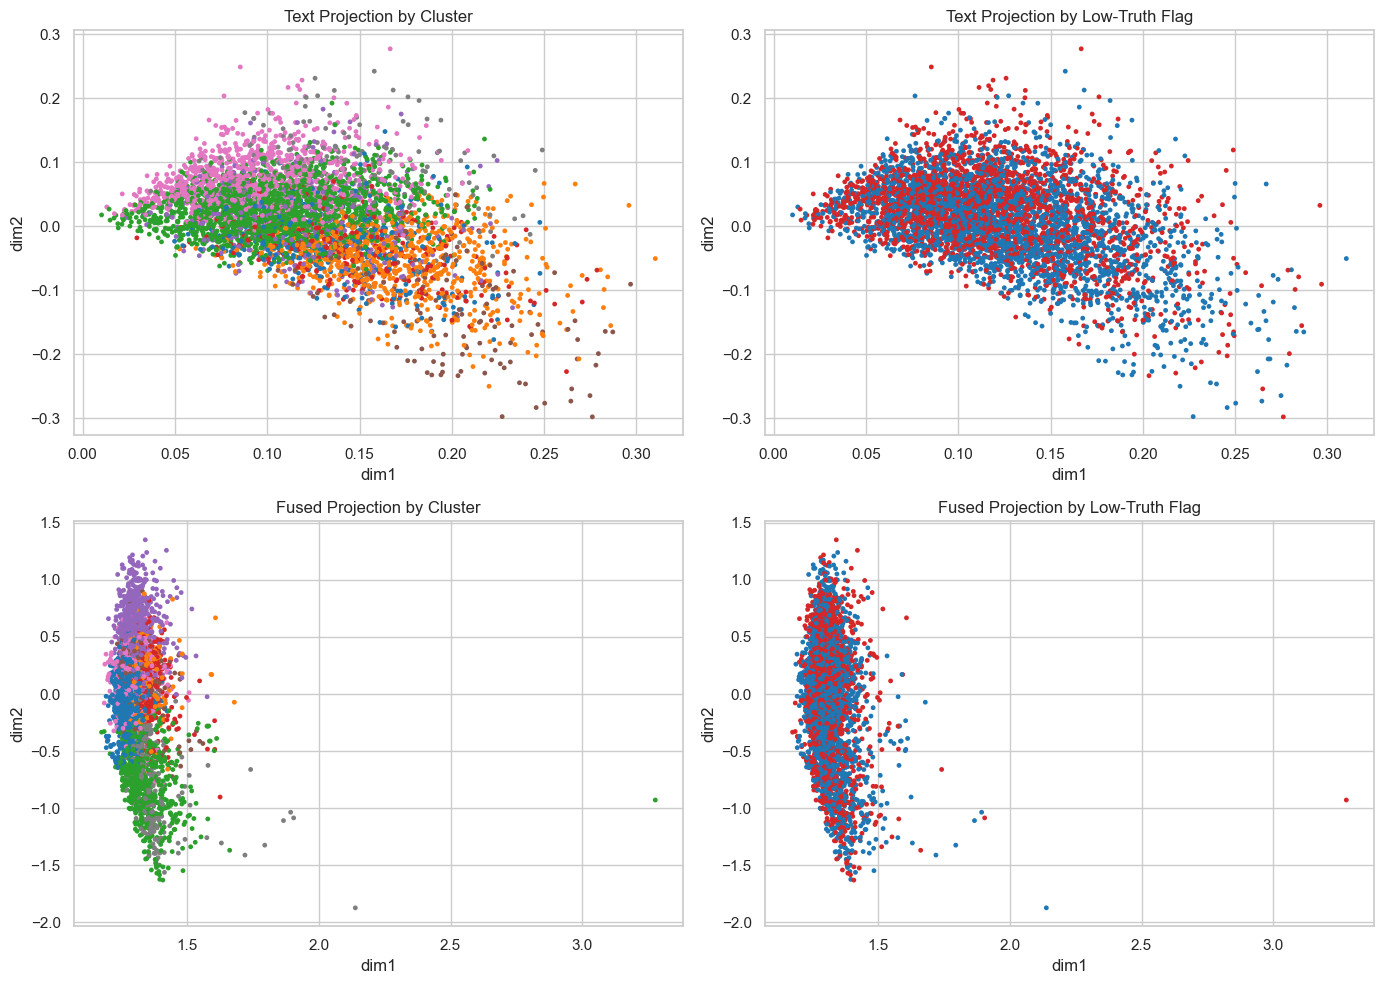

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
for i, src in enumerate(sources):
    proj_path = proc / f'clusters_{src}_projection.parquet'
    if not proj_path.exists():
        continue
    proj = pd.read_parquet(proj_path)
    sample = proj.sample(min(5000, len(proj)), random_state=42)
    sns.scatterplot(data=sample, x='dim1', y='dim2', hue='cluster_id', palette='tab10', s=12, linewidth=0, ax=ax[i,0], legend=False)
    ax[i,0].set_title(f'{src.title()} Projection by Cluster')
    sns.scatterplot(data=sample, x='dim1', y='dim2', hue='is_low_truth', palette={0:'#1f77b4',1:'#d62728'}, s=12, linewidth=0, ax=ax[i,1], legend=False)
    ax[i,1].set_title(f'{src.title()} Projection by Low-Truth Flag')
plt.tight_layout()
plt.show()

In [7]:
for src in sources:
    p = proc / f'clusters_{src}_label_distribution.csv'
    if not p.exists():
        continue
    label_dist = pd.read_csv(p)
    cluster_totals = label_dist.groupby('cluster_id')['count'].sum().rename('cluster_total')
    purity = label_dist.join(cluster_totals, on='cluster_id')
    purity['pct_in_cluster'] = purity['count'] / purity['cluster_total']
    print(f'--- Top 3 labels per cluster: {src} ---')
    display(purity.sort_values(['cluster_id','pct_in_cluster'], ascending=[True,False]).groupby('cluster_id').head(3))

--- Top 3 labels per cluster: text ---


,cluster_id,label,count,cluster_total,pct_in_cluster
0,0,mostly-true,220,872,0.252294
1,0,half-true,218,872,0.250000
2,0,true,196,872,0.224771
6,1,mostly-true,448,2011,0.222775
7,1,half-true,391,2011,0.194431
8,1,true,384,2011,0.190950
12,2,half-true,928,4634,0.200259
13,2,false,921,4634,0.198748
14,2,mostly-true,858,4634,0.185153
18,3,mostly-true,221,786,0.281170


--- Top 3 labels per cluster: fused ---


,cluster_id,label,count,cluster_total,pct_in_cluster
0,0,half-true,762,3421,0.222742
1,0,mostly-true,711,3421,0.207834
2,0,false,594,3421,0.173633
6,1,false,169,755,0.223841
7,1,mostly-true,148,755,0.196026
8,1,true,148,755,0.196026
12,2,half-true,388,1861,0.208490
13,2,mostly-true,382,1861,0.205266
14,2,false,380,1861,0.204191
18,3,mostly-true,207,1000,0.207000


In [8]:
rules = pd.read_csv(proc / 'rules_low_truth.csv')
rules.sort_values(['lift','confidence'], ascending=False).head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({'subject=crime'}),frozenset({'subject=criminal-justice'}),0.040127,0.020506,0.012197,0.303965,14.823523,1.0,0.011374,1.407248,0.971524,0.251825,0.289393,0.449396
1,frozenset({'subject=criminal-justice'}),frozenset({'subject=crime'}),0.020506,0.040127,0.012197,0.594828,14.823523,1.0,0.011374,2.369048,0.952062,0.251825,0.577889,0.449396
2,frozenset({'subject=environment'}),frozenset({'subject=energy'}),0.035531,0.040304,0.015202,0.427861,10.615824,1.0,0.013770,1.677382,0.939171,0.250729,0.403833,0.402527
3,frozenset({'subject=energy'}),frozenset({'subject=environment'}),0.040304,0.035531,0.015202,0.377193,10.615824,1.0,0.013770,1.548584,0.943842,0.250729,0.354249,0.402527
4,frozenset({'subject=state-finances'}),frozenset({'subject=state-budget'}),0.021743,0.065936,0.015202,0.699187,10.604024,1.0,0.013769,3.105132,0.925826,0.209756,0.677952,0.464875
5,frozenset({'subject=state-budget'}),frozenset({'subject=state-finances'}),0.065936,0.021743,0.015202,0.230563,10.604024,1.0,0.013769,1.271393,0.969630,0.209756,0.213461,0.464875
6,frozenset({'subject=deficit'}),frozenset({'subject=federal-budget'}),0.018031,0.068057,0.012197,0.676471,9.939725,1.0,0.010970,2.880550,0.915908,0.165072,0.652844,0.427846
7,frozenset({'subject=terrorism'}),frozenset({'subject=foreign-policy'}),0.033587,0.051617,0.012374,0.368421,7.137527,1.0,0.010640,1.501606,0.889780,0.169903,0.334046,0.304074
8,frozenset({'subject=foreign-policy'}),frozenset({'subject=terrorism'}),0.051617,0.033587,0.012374,0.239726,7.137527,1.0,0.010640,1.271138,0.906697,0.169903,0.213303,0.304074
9,frozenset({'subject=military'}),frozenset({'subject=foreign-policy'}),0.028637,0.051617,0.010076,0.351852,6.816527,1.0,0.008598,1.463219,0.878454,0.143577,0.316575,0.273529


In [9]:
anom = pd.read_csv(proc / 'anomaly_speakers_min_claims.csv')
anom.head(20)

,speaker,total_claims,anomaly_rate,low_truth_rate
0,lynn-westmoreland,8,0.625000,0.250000
1,ed-lindsey,5,0.600000,0.000000
2,vincent-fort,5,0.600000,0.400000
3,charlie-hales,6,0.500000,0.333333
4,sid-miller,7,0.428571,0.571429
5,jd-hayworth,5,0.400000,0.600000
6,mary-nolan,5,0.400000,0.000000
7,richard-durbin,5,0.400000,0.400000
8,sam-olens,5,0.400000,0.200000
9,sam-adams,15,0.333333,0.333333


In [10]:
dups = pd.read_csv(proc / 'near_duplicate_pairs_filtered.csv')
dups.head(20), dups.shape

(          id_a        id_b  approx_jaccard
 0    2517.json   4435.json             1.0
 1    5894.json   7761.json             1.0
 2   11151.json   8905.json             1.0
 3    8918.json   8919.json             1.0
 4   10477.json  10586.json             1.0
 5   11898.json  12055.json             1.0
 6    1211.json   2519.json             1.0
 7    1093.json   2519.json             1.0
 8   11404.json  12942.json             1.0
 9    8589.json   8591.json             1.0
 10   1093.json   1211.json             1.0
 11   4913.json   4991.json             1.0
 12  11798.json   3062.json             1.0
 13  11798.json   5212.json             1.0
 14  11455.json  11527.json             1.0
 15   2855.json   3263.json             1.0
 16    192.json    209.json             1.0
 17   8589.json   8592.json             1.0
 18   8591.json   8592.json             1.0
 19    601.json    609.json             1.0,
 (67, 3))